In [210]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [211]:
data = pd.read_csv("final_cleaned_data.csv", sep=';')

In [212]:
data.head()

,Rank,Title,Artists,Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,...,# of Artist,Artist (Ind.),# of Nationality,Nationality,Continent,Points (Total),Points (Ind for each Artist/Nat),id,Song URL,Loudness_norm
0,1,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2023-05-29,0.668,0.758,-5.176,0.033,0.483,0.000,...,Artist 1,Eslabon Armado,Nationality 1,Mexico,Latin-America,200,100.0,3qQbCzHBycnDpGskqOWY0E,https://open.spotify.com/track/3qQbCzHBycnDpGs...,0.849862
1,2,WHERE SHE GOES,Bad Bunny,2023-05-29,0.652,0.800,-4.019,0.061,0.143,0.629,...,Artist 1,Bad Bunny,Nationality 1,Puerto Rico,Latin-America,199,199.0,7ro0hRteUMfnOioTFI5TG1,https://open.spotify.com/track/7ro0hRteUMfnOio...,0.883423
2,3,La Bebe - Remix,"Yng Lvcas, Peso Pluma",2023-05-29,0.812,0.479,-5.678,0.333,0.213,0.000,...,Artist 1,Yng Lvcas,Nationality 1,Mexico,Latin-America,198,99.0,2UW7JaomAMuX9pZrjVpHAU,https://open.spotify.com/track/2UW7JaomAMuX9pZ...,0.835301
3,4,Cupid - Twin Ver.,FIFTY FIFTY,2023-05-29,0.783,0.592,-8.332,0.033,0.435,0.000,...,Artist 1,FIFTY FIFTY,Nationality 1,South Korea,Asia,197,197.0,7FbrGaHYVDmfr7KoLIZnQ7,https://open.spotify.com/track/7FbrGaHYVDmfr7K...,0.758318
4,5,un x100to,"Grupo Frontera, Bad Bunny",2023-05-29,0.569,0.724,-4.076,0.047,0.228,0.000,...,Artist 1,Grupo Frontera,Nationality 1,Mexico,Latin-America,196,98.0,6pD0ufEQq0xdHSsRbg9LBK,https://open.spotify.com/track/6pD0ufEQq0xdHSs...,0.881769


In [213]:
subset = data[['Energy', 'Danceability']].dropna()

In [214]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(subset)

In [215]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

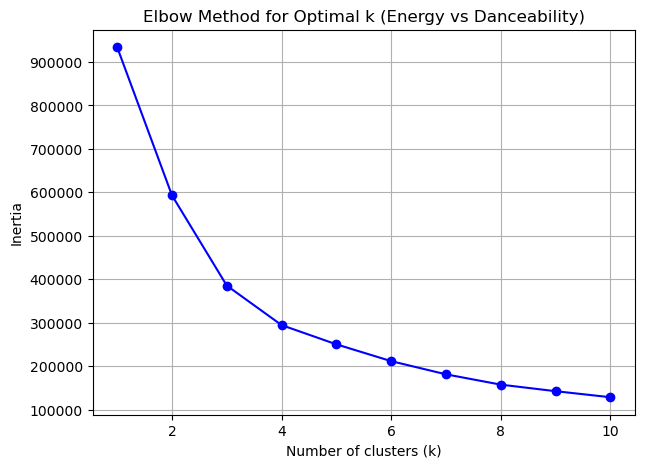

In [216]:
plt.figure(figsize=(7, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k (Energy vs Danceability)')
plt.grid(True)
plt.show()

In [217]:
optimal_k = 3  # You can adjust this based on the elbow curve
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
subset['Cluster'] = kmeans.fit_predict(scaled_features)

In [218]:
# Inverse transform the cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

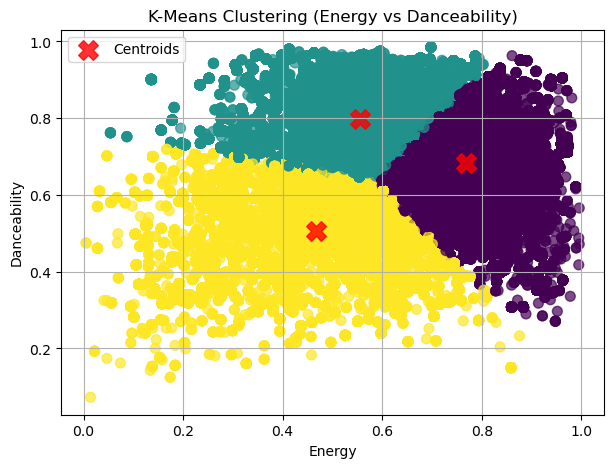

In [219]:
plt.figure(figsize=(7, 5))
plt.scatter(subset['Energy'], subset['Danceability'],
            c=subset['Cluster'], cmap='viridis', s=50, alpha=0.7)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1],
            c='red', s=200, alpha=0.8, marker='X', label='Centroids')

plt.title('K-Means Clustering (Energy vs Danceability)')
plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.legend()
plt.grid(True)
plt.show()

In [220]:
print("\nCluster Centers (Original Scale):")
for i, center in enumerate(centers):
    print(f"Cluster {i}: Energy={center[0]:.3f}, Danceability={center[1]:.3f}")
    
print("\nNumber of items in each cluster:")
print(subset['Cluster'].value_counts())


Cluster Centers (Original Scale):
Cluster 0: Energy=0.769, Danceability=0.682
Cluster 1: Energy=0.556, Danceability=0.799
Cluster 2: Energy=0.467, Danceability=0.506

Number of items in each cluster:
Cluster
0    214571
1    162020
2     90470
Name: count, dtype: int64


In [223]:
from sklearn.metrics import silhouette_score
 
 
silhouette_3 = silhouette_score(scaled_features, subset['Cluster'])
print(f"Silhouette score (k=3): {silhouette_3:.3f}")

Silhouette score (k=3): 0.369


In [221]:
def interpret_cluster(energy, Danceability):
    """Return a descriptive label based on cluster center characteristics."""
    if energy > 0.6 and Danceability > 0.6:
        return "🎉 High Energy & Happy songs (energetic, uplifting mood)"
    elif energy < 0.4 and Danceability < 0.4:
        return "💤 Low Energy & Sad songs (calm, mellow, emotional)"
    elif energy > 0.6 and Danceability < 0.4:
        return "🔥 Energetic but Dark songs (intense, aggressive tone)"
    elif energy < 0.4 and Danceability > 0.6:
        return "🌤️ Relaxed but Cheerful songs (chill, peaceful mood)"
    else:
        return "🎧 Moderate Energy & Neutral mood songs"

print("\nCluster Interpretations:")
for i, center in enumerate(centers):
    desc = interpret_cluster(center[0], center[1])
    print(f"Cluster {i}: {desc}")


Cluster Interpretations:
Cluster 0: 🎉 High Energy & Happy songs (energetic, uplifting mood)
Cluster 1: 🎧 Moderate Energy & Neutral mood songs
Cluster 2: 🎧 Moderate Energy & Neutral mood songs
